# Data Cleaning — `Tourist_Accommodation`

Limpieza de la tabla `Tourist_Accommodation` importada desde MySQL, partiendo de las conclusiones del EDA (`EDA_29_06_2026.ipynb y Data_Understanding_29_06_2026.pdf`).

**Puntos que se cubren:**
1. Corrección de tipos de datos
2. Eliminación o corrección de duplicados
3. Tratamiento de valores faltantes
4. Validación y corrección de valores atípicos
5. Estandarización de formatos

**Salida final:** un único CSV limpio (`../Data/Tourist_Accommodation_clean.csv`) sobre el que se aplicará la fase de *Data Transformation*.

> **Alcance de esta fase.** Aquí solo se limpia y se corrigen tipos/formatos. **NO** se hacen aquí (van en *Transformation*):
> - Reescalado de reseñas/puntuaciones: `review_scores_rating` 0–1000 → 0–100 y sub-puntuaciones 0–100 → 0–10 (lo hace Dídac).
> - Paso de `is_instant_bookable` a 0/1.
>
> No se elimina información salvo lo estrictamente necesario (versiones antiguas de un mismo alojamiento).

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mysql.connector
from pathlib import Path
from getpass import getpass

pd.set_option('display.max_columns', None)

In [24]:
conexion = mysql.connector.connect(
    host="212.227.148.202",
    port=3306,
    user="Equipo34",
    password="E1q2u3i4p5o34",
    database="Equip_34"
)

df = pd.read_sql(
    "SELECT * FROM Tourist_Accommodation;",
    conexion
)

print("Dimensiones originales:", df.shape)
df.head()

C:\Users\shadow\AppData\Local\Temp\ipykernel_21312\2501654414.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Dimensiones originales: (7001, 35)


,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2,1,1.0,"TV,Internet,Wifi,Air conditioning,Elevator,Buz...",400.0,3,365,VERDADERO,7,20,40,130,78,02/01/2010,05/09/2017,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,75.0,spain,malaga,31/07/2018
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1,1,1.0,"TV,Internet,Wifi,Air conditioning,Kitchen,Free...",170.0,4,40,VERDADERO,0,0,0,162,33,10/10/2014,15/07/2018,920.0,90.0,90.0,100.0,100.0,80.0,90.0,FALSO,52.0,spain,madrid,10/01/2020
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1,2,2.0,"TV,Internet,Wifi,Air conditioning,Wheelchair a...",990.0,2,120,VERDADERO,26,31,31,270,148,05/01/2011,22/07/2019,980.0,100.0,100.0,100.0,100.0,100.0,100.0,VERDADERO,142.0,spain,sevilla,29/07/2019
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2,1,1.0,"TV,Internet,Wifi,Kitchen,Breakfast,Elevator,Bu...",400.0,2,730,VERDADERO,9,23,49,300,292,13/03/2012,04/01/2020,940.0,100.0,90.0,100.0,100.0,100.0,90.0,VERDADERO,306.0,spain,barcelona,10/01/2020
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1,2,5.0,"Wifi,Pool,Free parking on premises,Breakfast,P...",900.0,1,180,VERDADERO,0,19,49,312,36,08/07/2011,08/08/2018,970.0,100.0,100.0,100.0,100.0,100.0,100.0,FALSO,39.0,spain,girona,19/02/2019


In [25]:
# Copia de trabajo para no alterar el DataFrame original importado
df_clean = df.copy()

## 1. Corrección de tipos de datos

- `bathrooms` y `bedrooms` llegan como texto (`object`) aunque son recuentos → a entero nullable (`Int64`, admite nulos).
- `beds` se homogeneiza también a entero nullable.
- Fechas (`first_review_date`, `last_review_date`, `insert_date`) están como texto `dd/mm/aaaa` → a `datetime`.

In [26]:
# --- Recuentos que venían como texto -> entero nullable (Int64) ---
count_cols = ['bathrooms', 'bedrooms', 'beds']
for col in count_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').astype('Int64')

# --- Fechas dd/mm/aaaa -> datetime ---
date_cols = ['first_review_date', 'last_review_date', 'insert_date']
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], format='%d/%m/%Y', errors='coerce')

df_clean[count_cols + date_cols].dtypes

bathrooms                     Int64
bedrooms                      Int64
beds                          Int64
first_review_date    datetime64[us]
last_review_date     datetime64[us]
insert_date          datetime64[us]
dtype: object

In [27]:
# Comprobación: la conversión no debe crear nulos "nuevos" inesperados
print("Nulos tras convertir tipos (deben coincidir con los originales):")
for col in count_cols + date_cols:
    print(f"  {col:20s} nulos: {df_clean[col].isna().sum():5d}  |  original: {df[col].isna().sum()}")

Nulos tras convertir tipos (deben coincidir con los originales):
  bathrooms            nulos:    32  |  original: 32
  bedrooms             nulos:    29  |  original: 29
  beds                 nulos:     3  |  original: 3
  first_review_date    nulos:  1254  |  original: 1254
  last_review_date     nulos:  1255  |  original: 1255
  insert_date          nulos:     0  |  original: 0


## 2. Eliminación o corrección de duplicados

No hay filas completamente idénticas, pero sí `apartment_id` repetidos: el mismo alojamiento volcado en fechas distintas. Se conserva únicamente la **última foto** (máximo `insert_date`) de cada `apartment_id`.

In [28]:
# Filas 100% duplicadas
print("Filas completamente duplicadas:", df_clean.duplicated().sum())

# apartment_id repetidos (mismo alojamiento en distintos volcados)
rep = df_clean['apartment_id'].value_counts()
rep = rep[rep > 1]
print(f"apartment_id repetidos: {rep.shape[0]}  (filas implicadas: {int(rep.sum())})")
print("Fecha global mas reciente de volcado (insert_date):", df_clean['insert_date'].max().date())

# Nos quedamos con el registro de mayor insert_date por apartment_id
antes = len(df_clean)
df_clean = (
    df_clean.sort_values('insert_date')
            .drop_duplicates(subset='apartment_id', keep='last')
            .reset_index(drop=True)
)
print(f"\nRegistros eliminados (versiones antiguas): {antes - len(df_clean)}")
print("Dimensiones tras deduplicar:", df_clean.shape)
print("apartment_id unico ahora?", df_clean['apartment_id'].is_unique)

Filas completamente duplicadas: 0
apartment_id repetidos: 261  (filas implicadas: 529)
Fecha global mas reciente de volcado (insert_date): 2021-02-27

Registros eliminados (versiones antiguas): 268
Dimensiones tras deduplicar: (6733, 35)
apartment_id unico ahora? True


## 3. Tratamiento de valores faltantes

Se **conservan** los registros con nulos (no se eliminan) y **no se imputan** valores que puedan sesgar los análisis posteriores:

- `review_scores_*`, `first_review_date`, `last_review_date`, `reviews_per_month`: nulos **estructurales** = alojamientos sin reseñas (`number_of_reviews = 0`). Se dejan como nulos.
- `has_availability`: solo `VERDADERO` + nulos (no hay `FALSO`); los nulos se dejan como desconocido (no se convierten a falso).
- `neighbourhood_district`, `price`, `bathrooms`, `bedrooms`, `beds`, `name`, `description`: se conservan sin imputar.

*(Si en Transformation se decide imputar `price` o tratar `has_availability`, se hará allí con criterio de negocio.)*

In [29]:
# Panorama de nulos tras deduplicar
nulos = pd.DataFrame({
    "nulos": df_clean.isnull().sum(),
    "%": (df_clean.isnull().mean() * 100).round(2)
})
nulos[nulos["nulos"] > 0].sort_values("%", ascending=False)

,nulos,%
neighbourhood_district,2658,39.48
review_scores_value,1289,19.14
review_scores_location,1289,19.14
review_scores_checkin,1288,19.13
review_scores_accuracy,1283,19.06
review_scores_communication,1279,19.00
review_scores_cleanliness,1277,18.97
review_scores_rating,1274,18.92
last_review_date,1204,17.88
first_review_date,1203,17.87


In [30]:
# Los nulos de valoraciones son estructurales: alojamientos sin reseñas
sin_reviews = df_clean['number_of_reviews'] == 0
print("Alojamientos con number_of_reviews == 0 :", sin_reviews.sum())
print("  de ellos con review_scores_rating nulo:", (sin_reviews & df_clean['review_scores_rating'].isna()).sum())
print("Con reseñas (>0) pero rating nulo (nulo real, no estructural):",
      ((~sin_reviews) & df_clean['review_scores_rating'].isna()).sum())

print("\nhas_availability (solo VERDADERO + nulos, sin FALSO):")
print(df_clean['has_availability'].value_counts(dropna=False))

Alojamientos con number_of_reviews == 0 : 1200
  de ellos con review_scores_rating nulo: 1200
Con reseñas (>0) pero rating nulo (nulo real, no estructural): 74

has_availability (solo VERDADERO + nulos, sin FALSO):
has_availability
VERDADERO    6199
NaN           534
Name: count, dtype: int64


## 4. Validación y corrección de valores atípicos

Confirmamos que los valores extremos son plausibles (no errores) y los **mantenemos**. Solo se revisa coherencia; no se elimina nada.

> `reviews_per_month` presenta valores muy altos (máx ≈ 1291). Parece estar escalado (×100) respecto al valor mensual real; **no se corrige aquí**, se revisará junto con el reescalado de reseñas en *Transformation*.

In [31]:
num_check = ['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
             'minimum_nights', 'maximum_nights', 'number_of_reviews', 'reviews_per_month']
df_clean[num_check].describe().round(2)

,price,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,number_of_reviews,reviews_per_month
count,6612.00,6733.00,6702.0,6704.0,6730.0,6733.00,6733.00,6733.00,5530.00
mean,1009.36,4.35,1.61,1.97,3.01,4.42,756.98,34.17,122.62
std,844.75,2.63,0.99,1.3,2.34,10.78,498.75,60.21,152.25
min,60.00,1.00,0.0,0.0,0.0,1.00,1.00,0.00,1.00
25%,450.00,2.00,1.0,1.0,1.0,1.00,62.00,1.00,17.00
50%,750.00,4.00,1.0,2.0,2.0,2.00,1125.00,9.00,57.00
75%,1220.00,6.00,2.0,3.0,4.0,4.00,1125.00,40.00,176.00
max,6071.00,29.00,12.0,16.0,30.0,365.00,1125.00,588.00,1273.00


In [32]:
# Recuento de outliers por IQR (solo informativo: NO se eliminan)
def n_outliers_iqr(s):
    s = s.dropna().astype(float)
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < low) | (s > high)).sum())

resumen_out = pd.Series({c: n_outliers_iqr(df_clean[c]) for c in num_check}, name='outliers_IQR')
print(resumen_out.to_string())

# Casos limite coherentes que SE CONSERVAN (pueden aportar info en otras columnas)
print("\nAlojamientos con beds == 0      :", int((df_clean['beds'] == 0).sum()), "(se conservan)")
print("Alojamientos con bathrooms == 0 :", int((df_clean['bathrooms'] == 0).sum()), "(se conservan)")
print("price -> min:", df_clean['price'].min(), "| max:", df_clean['price'].max(), "| nulos:", int(df_clean['price'].isna().sum()))

price                503
accommodates          61
bathrooms            322
bedrooms              33
beds                 169
minimum_nights       351
maximum_nights         0
number_of_reviews    690
reviews_per_month    350

Alojamientos con beds == 0      : 56 (se conservan)
Alojamientos con bathrooms == 0 : 14 (se conservan)
price -> min: 60.0 | max: 6071.0 | nulos: 121


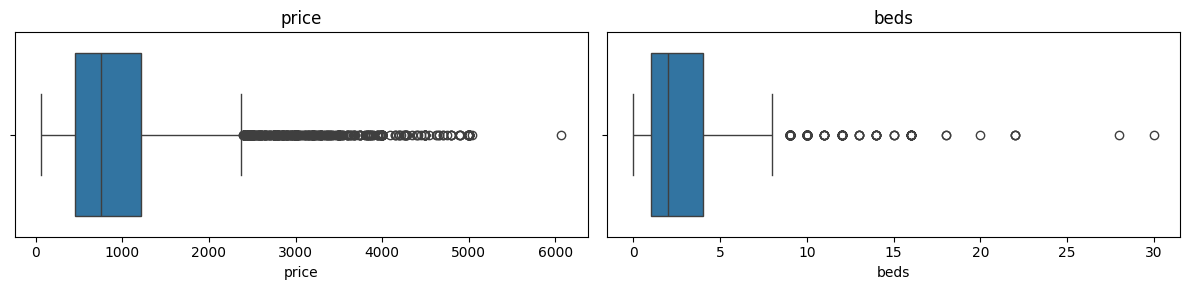

In [33]:
# Validacion visual de dos variables representativas (los outliers se mantienen)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
sns.boxplot(x=df_clean['price'], ax=axes[0]); axes[0].set_title('price')
sns.boxplot(x=df_clean['beds'].astype('float'), ax=axes[1]); axes[1].set_title('beds')
plt.tight_layout(); plt.show()

## 5. Estandarización de formatos

- Se eliminan espacios sobrantes en los campos de texto.
- `price` → se renombra a **`price_€`** y se mantiene como numérico.
- **Aviso de codificación:** varios textos (`name`, `neighbourhood_name`, `description`) contienen el carácter de reemplazo `�` en lugar de acentos, perdidos al volcar los datos a MySQL (p. ej. `Cadaqu�s` → *Cadaqués*). **No es recuperable** a nivel de string. Se documenta como limitación de origen y se deja el texto tal cual; si se quisiera corregir habría que construir un diccionario manual en *Transformation*.

In [34]:
# Espacios sobrantes en columnas de texto
text_cols = df_clean.select_dtypes(include=['object', 'str']).columns
for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

# price -> price_€ (se mantiene numerico)
df_clean = df_clean.rename(columns={'price': 'price_€'})
print("Columna de precio:", [c for c in df_clean.columns if 'price' in c], "| dtype:", df_clean['price_€'].dtype)

Columna de precio: ['price_€'] | dtype: float64


In [35]:
# Cuantificacion del problema de codificacion (informativo, no se altera el dato)
mojibake_cols = ['name', 'neighbourhood_name', 'description']
for col in mojibake_cols:
    n = df_clean[col].fillna('').str.contains('�').sum()
    print(f"{col:20s}: {n} registros con '�' (acento perdido en origen)")

name                : 1332 registros con '�' (acento perdido en origen)
neighbourhood_name  : 1477 registros con '�' (acento perdido en origen)
description         : 4587 registros con '�' (acento perdido en origen)


## 6. Verificación final y exportación a CSV

Se genera un **único CSV** con el resultado de la limpieza, listo para la fase de *Data Transformation*.

In [36]:
print("Dimensiones finales:", df_clean.shape)
print("apartment_id unico :", df_clean['apartment_id'].is_unique)
print("Filas duplicadas   :", df_clean.duplicated().sum())
print("\nTipos de datos finales:")
df_clean.info()

Dimensiones finales: (6733, 35)
apartment_id unico : True
Filas duplicadas   : 0

Tipos de datos finales:
<class 'pandas.DataFrame'>
RangeIndex: 6733 entries, 0 to 6732
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 6733 non-null   int64         
 1   name                         6730 non-null   str           
 2   description                  6706 non-null   str           
 3   host_id                      6733 non-null   int64         
 4   neighbourhood_name           6733 non-null   str           
 5   neighbourhood_district       4075 non-null   str           
 6   room_type                    6733 non-null   str           
 7   accommodates                 6733 non-null   int64         
 8   bathrooms                    6702 non-null   Int64         
 9   bedrooms                     6704 non-null   Int64         
 10  beds         

In [ ]:
# Exportacion del CSV final (una sola tabla limpia) para Data Transformation
output_dir = Path('..') / 'Data'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'clean_dataset_29_06_2026.csv'

# utf-8 (sin BOM) para un round-trip limpio con pandas en la fase siguiente
df_clean.to_csv(output_path, index=False, encoding='utf-8')

print("CSV limpio guardado en:", output_path.resolve())
print("Filas x columnas:", df_clean.shape)

CSV limpio guardado en: E:\informacion y documentos\Curso analisis de datos IT Academy\Simulador empresarial\ProjecteData\Equip_34\Data\Tourist_Accommodation_clean.csv
Filas x columnas: (6733, 35)
